# DNN (PyTorch)

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import classification_report
from ffnn import FFNN, evaluate_loss_accuracy
from text_features import CombinedVectorizer, encode_labels, decode_labels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

N_CLASSES = 5

device: cuda
device: cuda


In [2]:
df_train = pd.read_csv('../datasets/dataset_v2_train.csv', sep=';')
df_test  = pd.read_csv('../datasets/dataset_v2_test.csv',  sep=';')
df_val   = pd.read_csv('../datasets/dataset_v2_val.csv',   sep=';')

print(f'treino: {len(df_train)} | teste: {len(df_test)} | val: {len(df_val)}')
print('\ndistribuição de treino:')
print(df_train['Label'].value_counts())

treino: 3500 | teste: 750 | val: 750

distribuição de treino:
Label
Meta         700
Anthropic    700
Openai       700
Google       700
Human        700
Name: count, dtype: int64


## *pré-processamento*

In [3]:
train_texts = df_train['Text'].fillna('').tolist()
test_texts  = df_test['Text'].fillna('').tolist()

# TF-IDF: palavra (1,2)-grams + char (3,5)-grams
vec = CombinedVectorizer(max_words=5000, ngram_range=(1, 2),
                         max_chars=3000,  char_range=(3, 5))

X_train = vec.fit_transform(train_texts)
X_test  = vec.transform(test_texts)

Y_train = encode_labels(df_train['Label'].tolist())
Y_test  = encode_labels(df_test['Label'].tolist())

print(f'dimensão das features: {X_train.shape[1]}')

def make_loader(X, y, batch_size=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

Xt       = torch.tensor(X_train, dtype=torch.float32)
yt       = torch.tensor(Y_train, dtype=torch.long)
n_train  = int(0.85 * len(Y_train))
n_val    = len(Y_train) - n_train
train_ds, val_ds = random_split(TensorDataset(Xt, yt), [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)
test_loader  = make_loader(X_test, Y_test, batch_size=64)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

dimensão das features: 8000
X_train: (3500, 8000) | X_test: (750, 8000)


## *treino*

In [4]:
class_weights = torch.tensor([3.0, 4.0, 2.0, 5.0, 0.5], dtype=torch.float32).to(device)

input_dim = X_train.shape[1]
model_dnn = FFNN(input_dim=input_dim, n_classes=N_CLASSES,
                 topology=[128, 64], dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_dnn.parameters(), lr=0.001, weight_decay=1e-3)

NUM_EPOCHS = 100
PATIENCE   = 15

best_val_acc = 0.0
best_state   = None
no_improve   = 0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    model_dnn.train()
    running_loss    = 0.0
    running_correct = 0
    running_total   = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_dnn(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * xb.size(0)
        preds            = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total   += yb.size(0)

    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total
    val_loss, val_acc = evaluate_loss_accuracy(model_dnn, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in model_dnn.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'early stopping na época {epoch}')
            break

model_dnn.load_state_dict(best_state)
print(f'\nmelhor modelo -> val_acc={best_val_acc:.4f}')

Epoch 010/100 | train_loss=0.0544 | train_acc=0.9714 | val_loss=0.0121 | val_acc=0.9848
Epoch 020/100 | train_loss=0.0411 | train_acc=0.9852 | val_loss=0.0074 | val_acc=0.9905
Epoch 030/100 | train_loss=0.0402 | train_acc=0.9862 | val_loss=0.0082 | val_acc=0.9962
Epoch 040/100 | train_loss=0.0313 | train_acc=0.9903 | val_loss=0.0135 | val_acc=0.9810
early stopping na época 49

melhor modelo -> val_acc=0.9981


## *avaliação*

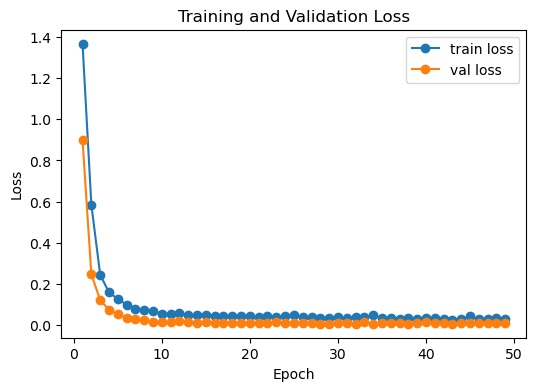

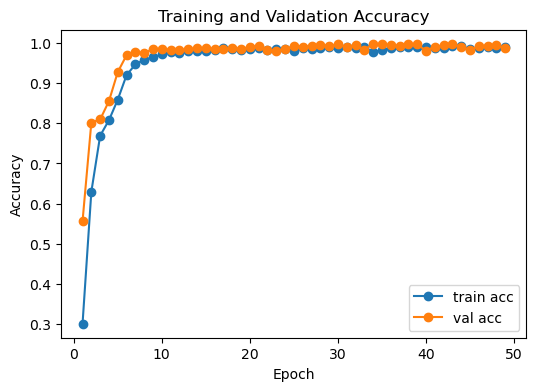

[TRAIN] accuracy=1.0000
[TEST]  accuracy=0.9987


In [5]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_losses, marker='o', label='train loss')
plt.plot(epochs_range, val_losses,   marker='o', label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_accs, marker='o', label='train acc')
plt.plot(epochs_range, val_accs,   marker='o', label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

_, train_acc = evaluate_loss_accuracy(model_dnn, DataLoader(train_ds, batch_size=64), criterion)
_, test_acc  = evaluate_loss_accuracy(model_dnn, test_loader, criterion)
print(f'[TRAIN] accuracy={train_acc:.4f}')
print(f'[TEST]  accuracy={test_acc:.4f}')

In [6]:
torch.save(model_dnn.state_dict(), '../models/model_dnn.pt')

with open('../vectorizers/vectorizer_dnn.pkl', 'wb') as f:
    pickle.dump(vec, f)

print('modelo e vectorizer guardados.')

modelo e vectorizer guardados.


## *avaliação com dataset-exemplos*

In [7]:
df_ex = pd.read_csv('../datasets/dataset-exemplos.csv', sep=';')
X_ex  = vec.transform(df_ex['Text'].fillna('').tolist())
Y_ex  = encode_labels(df_ex['Label'].tolist())
ex_loader = make_loader(X_ex, Y_ex, batch_size=64)

model_dnn.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in ex_loader:
        logits = model_dnn(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_ex['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

              precision    recall  f1-score   support

   anthropic      0.857     0.261     0.400        23
      google      0.562     0.562     0.562        16
       human      0.580     0.904     0.707        52
        meta      0.462     0.353     0.400        17
      openai      0.250     0.118     0.160        17

    accuracy                          0.560       125
   macro avg      0.542     0.440     0.446       125
weighted avg      0.568     0.560     0.516       125



## *avaliação com Subm1*

In [8]:
df_subm1     = pd.read_csv('../Subm1/subm1_labels_revealed.csv', sep=';')
X_subm1      = vec.transform(df_subm1['Text'].fillna('').tolist())
Y_subm1      = encode_labels(df_subm1['Label'].tolist())
subm1_loader = make_loader(X_subm1, Y_subm1, batch_size=64)

model_dnn.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in subm1_loader:
        logits = model_dnn(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_subm1['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

              precision    recall  f1-score   support

   anthropic      1.000     0.294     0.455        17
      google      0.462     0.353     0.400        17
       human      0.721     0.912     0.805        34
        meta      0.542     0.722     0.619        18
      openai      0.200     0.214     0.207        14

    accuracy                          0.580       100
   macro avg      0.585     0.499     0.497       100
weighted avg      0.619     0.580     0.559       100

